# RQ1: Individual Influential Factors in Trend Classification

**Research question:** What factors, such as platform, region, content category, traffic source, and engagement metrics, most strongly influence video trend classification?


## 1. Load Processed Data

The preprocessing notebook already cleaned missing values, encoded categorical variables, and saved numeric train/validation/test files.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score

train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")
feature_metadata = pd.read_csv("../data/processed/feature_metadata.csv")

TARGET = "trend_label"

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

display(y_train.value_counts(normalize=True).sort_index())
display(feature_metadata.head())

Train: (33655, 203) (33655,)
Validation: (7212, 203) (7212,)
Test: (7212, 203) (7212,)


trend_label
declining    0.249651
rising       0.251701
seasonal     0.252622
stable       0.246026
Name: proportion, dtype: float64

,feature,original_feature,feature_group
0,week_of_year,week_of_year,temporal
1,duration_sec,duration_sec,content_basic
2,views,views,engagement_observed
3,likes,likes,engagement_observed
4,comments,comments,engagement_observed


## 2. Feature Inventory


In [4]:
feature_inventory = pd.DataFrame([
    {
        "feature": column,
        "dtype": str(X_train[column].dtype),
        "missing_rate": X_train[column].isna().mean(),
        "n_unique": X_train[column].nunique(dropna=True),
    }
    for column in X_train.columns
]).sort_values("n_unique", ascending=True)

print("Number of model features:", len(feature_inventory))
display(feature_inventory.head(50))

Number of model features: 203


,feature,dtype,missing_rate,n_unique
30,platform_youtube,int64,0.0,2
31,country_ae,int64,0.0,2
19,is_weekend,int64,0.0,2
29,platform_tiktok,int64,0.0,2
16,has_emoji,int64,0.0,2
58,country_tr,int64,0.0,2
57,country_se,int64,0.0,2
56,country_sa,int64,0.0,2
55,country_ru,int64,0.0,2
54,country_pl,int64,0.0,2


## 3. Baseline and Random Forest Model


In [5]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=50,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rows = []
for model_name, model in [
    ("majority_baseline", baseline),
    ("random_forest", rf),
]:
    for split_name, X_part, y_part in [
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        y_pred = model.predict(X_part)
        rows.append({
            "model": model_name,
            "split": split_name,
            "accuracy": accuracy_score(y_part, y_pred),
            "macro_f1": f1_score(y_part, y_pred, average="macro"),
        })

model_scores = pd.DataFrame(rows).sort_values(["split", "macro_f1"], ascending=[True, False])
display(model_scores.round(4))

,model,split,accuracy,macro_f1
3,random_forest,test,0.2454,0.2454
1,majority_baseline,test,0.2526,0.1008
2,random_forest,validation,0.2622,0.2621
0,majority_baseline,validation,0.2526,0.1008


              precision    recall  f1-score   support

   declining      0.250     0.248     0.249      1800
      rising      0.264     0.273     0.268      1816
    seasonal      0.289     0.279     0.284      1822
      stable      0.246     0.248     0.247      1774

    accuracy                          0.262      7212
   macro avg      0.262     0.262     0.262      7212
weighted avg      0.262     0.262     0.262      7212



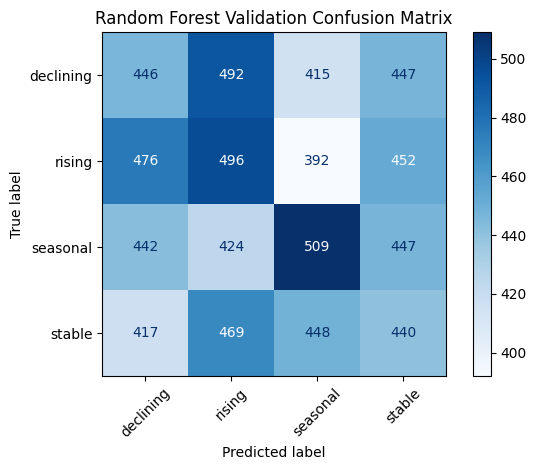

In [6]:
y_val_pred = rf.predict(X_val)

print(classification_report(y_val, y_val_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    xticks_rotation=45,
    cmap="Blues",
)
plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Feature Importance

Random forest importance is first calculated for encoded model columns, then aggregated back to the original feature names saved by preprocessing.


In [ ]:
encoded_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

encoded_importance = encoded_importance.merge(feature_metadata, on="feature", how="left")

factor_importance = (
    encoded_importance.dropna(subset=["original_feature", "feature_group"])
    .groupby(["original_feature", "feature_group"], as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

top_factors = factor_importance.head(20)

display(top_factors.round(4))

,original_feature,feature_group,importance
4,completion_rate,engagement_observed,0.0332
34,save_rate,engagement_observed,0.0326
6,creator_avg_views,creator,0.0324
25,like_dislike_ratio,engagement_observed,0.0321
10,dislike_rate,engagement_observed,0.0320
0,avg_watch_time_sec,engagement_observed,0.0312
2,comment_ratio,engagement_observed,0.0312
37,share_rate,engagement_observed,0.0311
17,engagement_share_rate,engagement_observed,0.0308
35,saves,engagement_observed,0.0305


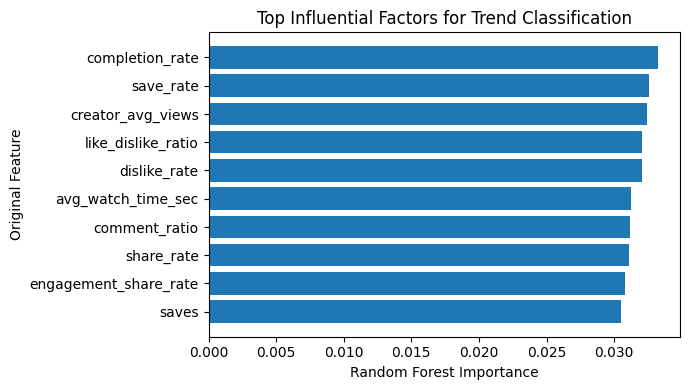

In [17]:
plt.figure(figsize=(7, 4))
plt.barh(top_factors["original_feature"], top_factors["importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Original Feature")
plt.title("Top Influential Factors for Trend Classification")
plt.tight_layout()
plt.show()

## 5. Optionally filter features


In [ ]:
""" rq1_features = [
    "platform",
    "region",
    "country",
    "language",
    "category",
    "genre",
    "traffic_source",
    "views",
    "likes",
    "comments",
    "shares",
    "saves",
    "engagement_rate",
    "comment_ratio",
    "share_rate",
    "save_rate",
    "completion_rate",
    "avg_watch_time_sec",
]

rq1_table = factor_importance[
    factor_importance["original_feature"].isin(rq1_features)
].copy()

display(rq1_table.round(4)) """

,original_feature,feature_group,importance
4,completion_rate,engagement_observed,0.0332
34,save_rate,engagement_observed,0.0326
0,avg_watch_time_sec,engagement_observed,0.0312
2,comment_ratio,engagement_observed,0.0312
37,share_rate,engagement_observed,0.0311
35,saves,engagement_observed,0.0305
43,views,engagement_observed,0.0297
38,shares,engagement_observed,0.0295
3,comments,engagement_observed,0.0292
27,likes,engagement_observed,0.0288
